
# 01 — Business EDA (V3) — CFO-grade KPIs & Harmonized Visuals

This version keeps the **same clean visual grammar** while aligning all **comments/markdown to English** and adding the requested micro-iterations:

- **CFO definitions** for retention metrics (**Gross churn on Opening ARR, GRR, NRR, Quick ratio**)
- **Reactivated ARR** explicitly surfaced as a first-class KPI
- **Waterfalls** (Opening → −Churn → +Reactivation → +New → Closing) — global and by segment
- **Standardized labels**: *Revenue churn (ARR% on stock)* vs *Logo churn (% of logos)*
- **Benchmarks & definitions** slide for executive alignment
- **Prioritization matrix** (Region × Segment net contribution %) to guide actions

> Data source: `saas_financial_snapshot.csv` (from Data Treatment V5)


In [101]:

import sys
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add src/ to path for shared KPI function
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
src_path = project_root / 'src' / 'decision_engine'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

try:
    from kpis import compute_cfo_kpis
    from heatmap_region_segment import plot_region_segment_heatmap
except ImportError as e:
    raise ImportError(
        f"Failed to import compute_cfo_kpis: {e}. "
        "Check src/decision_engine/kpis.py and heatmap_region_segment.py."
    )

# Harmonized visual style
sns.set_theme(style="white")
plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.figsize": (10, 5),
})
plt.rcParams['axes.grid'] = False  # remove background gridlines globally
plt.rcParams['axes.unicode_minus'] = False  # ensure minus signs render as hyphen-minus even with fonts

# Formatting helpers (USD)
fmt_usd = lambda x: f"{x:,.0f} $".replace(",", " ")
fmt_pct = lambda x: f"{x*100:,.1f}%".replace(",", " ")

# Million USD helpers
to_MUSD = lambda x: x / 1e6
fmt_MUSD = lambda x: f"{x:,.1f} M$"



## Load data


In [102]:

path = Path(r"C:\ai-decision-intelligence-main\data\processed\saas_financial_snapshot.csv")
df = pd.read_csv(path)

# Expected schema
expected_cols = {
    'account_id','industry','country','plan_tier','region','segment',
    'gross_margin_estimated','annual_contract_value','opening_arr',
    'new_arr','churned_arr','reactivated_arr','expansion_arr','contraction_arr',
    'net_arr_change','analysis_window_start','analysis_window_end'
}
missing = expected_cols.difference(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Numeric normalization
for col in ['annual_contract_value','opening_arr','new_arr','churned_arr','reactivated_arr','expansion_arr','contraction_arr','net_arr_change']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

# Basic cleanup
df['segment'] = df['segment'].fillna('SMB')

dash_chars = r"[\u2010\u2011\u2012\u2013\u2014\u2212]"
df['segment'] = df['segment'].str.replace(dash_chars, '-', regex=True)
df['region'] = df['region'].str.replace(dash_chars, '-', regex=True)

# Order segments by size (Enterprise → Corporate → SMB)
segment_order = ['Enterprise','Corporate','SMB']
df['segment'] = pd.Categorical(df['segment'], categories=segment_order, ordered=True)

window = (
    str(pd.to_datetime(df['analysis_window_start'].iloc[0]).date())
    + " → " + 
    str(pd.to_datetime(df['analysis_window_end'].iloc[0]).date())
)
window

'2024-01-01 → 2024-12-31'

## CFO KPIs

**Key Metrics:**
- **Net ARR**: New + Reactivated + Expansion - Churned - Contraction
- **GRR** (Gross Retention Rate): 1 - (Churned / Opening ARR) 
- **NRR** (Net Retention Rate): (Opening - Churned + Expansion - Contraction) / Opening ARR
- **Net Growth %**: Net ARR Change / Opening ARR
  - Direct measure of period ARR growth
  - **Positive** = Growing 
  - **Negative** = Decreasing 



These KPIs are the decision levers that drive scenario comparisons and budget trade-offs. They will be used further in the Decision Engine to evaluate policy impact and optimize allocations, so it remains the single source of truth for full KPI reporting.

In [103]:
# CFO KPIs (computed with shared function)
kpi_input = df.rename(columns={
    'opening_arr': 'opening',
    'churned_arr': 'churned',
    'new_arr': 'new',
    'reactivated_arr': 'reactivated',
    'expansion_arr': 'expansion',
    'contraction_arr': 'contraction',
})

cfo_global = compute_cfo_kpis(
    kpi_input[['opening','churned','new','reactivated','expansion','contraction']].sum().to_frame().T
 )

# Format for readability (M$ and %)
cfo_display = cfo_global.copy()
for col in ['opening','churned','new','reactivated','expansion','contraction','net']:
    cfo_display[col] = fmt_usd(cfo_display[col].iat[0])
for col in ['gross_churn','GRR','NRR','net_growth_pct']:
    cfo_display[col] = fmt_pct(cfo_display[col].iat[0])

display(cfo_display.style.set_table_styles([
    {"selector": "th, td", "props": [("white-space", "nowrap")]}
]))


,opening,churned,new,reactivated,expansion,contraction,net,gross_churn,GRR,NRR,net_growth_pct
0,4 891 680 $,1 439 928 $,9 281 448 $,3 777 048 $,0 $,0 $,11 618 568 $,29.4%,70.6%,70.6%,237.5%



## Segments — revenue vs logo churn, GRR/NRR

> **Labels**
> - *Revenue churn (ARR% on stock)* = `churned_arr / annual_contract_value`
> - *Logo churn (%)* = `% of accounts with churned_arr > 0`
> - *GRR/NRR* computed **on Opening ARR**


In [104]:

seg = df.groupby('segment').agg(
    opening_arr=('opening_arr','sum'),
    annual_contract_value=('annual_contract_value','sum'),
    churned_arr=('churned_arr','sum'),
    new_arr=('new_arr','sum'),
    reactivated_arr=('reactivated_arr','sum'),
    expansion_arr=('expansion_arr','sum'),
    contraction_arr=('contraction_arr','sum'),
    accounts=('account_id','nunique'),
    logos_churn=('churned_arr', lambda s: (s>0).mean())
).reset_index()

seg['segment'] = pd.Categorical(seg['segment'], categories=segment_order, ordered=True)
seg = seg.sort_values('segment').reset_index(drop=True)

seg['rev_churn_ratio_on_stock'] = seg['churned_arr'] / seg['annual_contract_value']
seg['gross_churn_on_opening'] = seg['churned_arr'] / seg['opening_arr']
seg['GRR'] = 1 - seg['gross_churn_on_opening']
seg['NRR'] = (seg['opening_arr'] - seg['churned_arr'] + seg['expansion_arr'] - seg['contraction_arr']) / seg['opening_arr']

seg_fmt = seg.copy()
for c in ['opening_arr','annual_contract_value','churned_arr','new_arr','reactivated_arr','expansion_arr','contraction_arr']:
    seg_fmt[c] = seg_fmt[c].apply(fmt_usd)
for c in ['rev_churn_ratio_on_stock','gross_churn_on_opening','GRR','NRR','logos_churn']:
    seg_fmt[c] = seg_fmt[c].apply(fmt_pct)

display(seg_fmt.style.set_table_styles([
    {"selector": "th, td", "props": [("white-space", "nowrap")]}
]))

,segment,opening_arr,annual_contract_value,churned_arr,new_arr,reactivated_arr,expansion_arr,contraction_arr,accounts,logos_churn,rev_churn_ratio_on_stock,gross_churn_on_opening,GRR,NRR
0,Enterprise,1 392 156 $,5 047 320 $,372 144 $,2 406 084 $,1 071 012 $,0 $,0 $,154,13.0%,7.4%,26.7%,73.3%,73.3%
1,Corporate,2 107 176 $,4 872 672 $,738 144 $,3 731 724 $,1 645 896 $,0 $,0 $,178,10.7%,15.1%,35.0%,65.0%,65.0%
2,SMB,1 392 348 $,4 914 024 $,329 640 $,3 143 640 $,1 060 140 $,0 $,0 $,168,8.9%,6.7%,23.7%,76.3%,76.3%


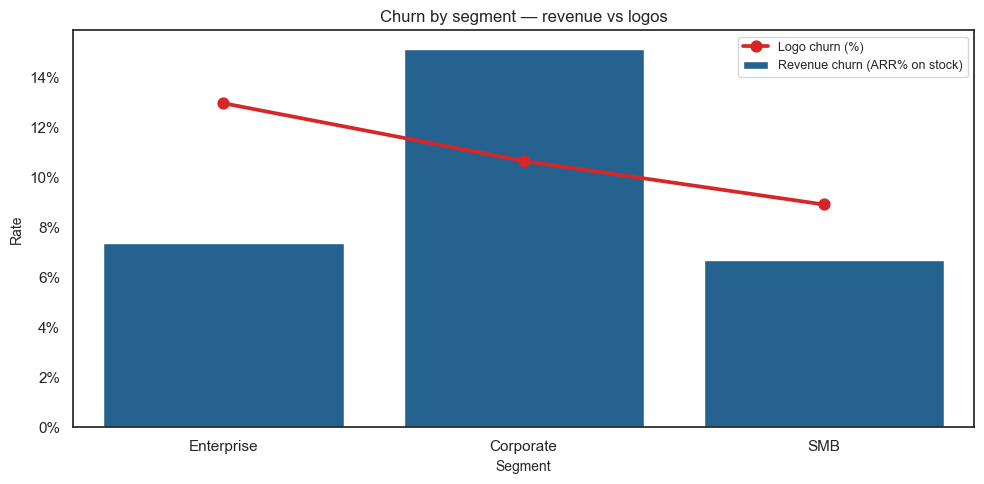

In [105]:

fig, ax = plt.subplots(figsize=(10,5))
order = segment_order
sns.barplot(
    data=seg, x='segment', y='rev_churn_ratio_on_stock', order=order,
    color='#1565a0', label='Revenue churn (ARR% on stock)')
sns.pointplot(
    data=seg, x='segment', y='logos_churn', order=order, color='#d62728', label='Logo churn (%)')
ax.set_title('Churn by segment — revenue vs logos')
ax.set_xlabel('Segment')
ax.set_ylabel('Rate')
ax.yaxis.set_major_formatter(lambda x,pos: f"{x*100:.0f}%")
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()



## Regions — GRR/NRR & churn


In [106]:

reg = df.groupby('region').agg(
    opening_arr=('opening_arr','sum'),
    annual_contract_value=('annual_contract_value','sum'),
    churned_arr=('churned_arr','sum'),
    new_arr=('new_arr','sum'),
    reactivated_arr=('reactivated_arr','sum'),
    expansion_arr=('expansion_arr','sum'),
    contraction_arr=('contraction_arr','sum'),
    accounts=('account_id','nunique'),
    logos_churn=('churned_arr', lambda s: (s>0).mean())
).reset_index()
reg['rev_churn_ratio_on_stock'] = reg['churned_arr'] / reg['annual_contract_value']
reg['gross_churn_on_opening'] = reg['churned_arr'] / reg['opening_arr']
reg['GRR'] = 1 - reg['gross_churn_on_opening']
reg['NRR'] = (reg['opening_arr'] - reg['churned_arr'] + reg['expansion_arr'] - reg['contraction_arr']) / reg['opening_arr']

reg_fmt = reg.copy()
for c in ['opening_arr','annual_contract_value','churned_arr','new_arr','reactivated_arr','expansion_arr','contraction_arr']:
    reg_fmt[c] = reg_fmt[c].apply(fmt_usd)
for c in ['rev_churn_ratio_on_stock','gross_churn_on_opening','GRR','NRR','logos_churn']:
    reg_fmt[c] = reg_fmt[c].apply(fmt_pct)

display(reg_fmt.style.set_table_styles([
    {"selector": "th, td", "props": [("white-space", "nowrap")]}
]))


,region,opening_arr,annual_contract_value,churned_arr,new_arr,reactivated_arr,expansion_arr,contraction_arr,accounts,logos_churn,rev_churn_ratio_on_stock,gross_churn_on_opening,GRR,NRR
0,APAC,906 228 $,2 810 220 $,159 456 $,1 578 324 $,506 484 $,0 $,0 $,81,8.6%,5.7%,17.6%,82.4%,82.4%
1,EMEA,819 900 $,3 905 028 $,310 800 $,1 862 616 $,904 308 $,0 $,0 $,105,13.3%,8.0%,37.9%,62.1%,62.1%
2,NAM,3 165 552 $,8 118 768 $,969 672 $,5 840 508 $,2 366 256 $,0 $,0 $,314,10.5%,11.9%,30.6%,69.4%,69.4%



## Prioritization matrix — Region × Segment net contribution (% of Region ARR)

This normalizes **Net ARR** by **Region ARR** to avoid size bias and quickly spot cells that deserve attention.


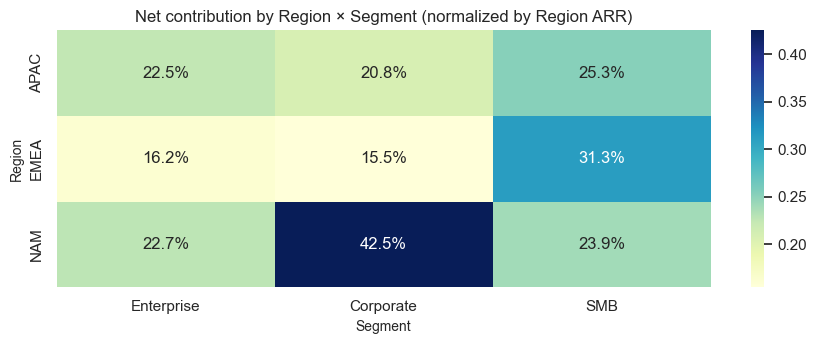

In [107]:
# Build Region x Segment matrix on normalized Net/ARR_region
agg = df.groupby(['region','segment']).agg(
    arr=('annual_contract_value','sum'),
    net=('net_arr_change','sum')
).reset_index()
reg_arr = agg.groupby('region')['arr'].sum().rename('arr_region')
agg = agg.merge(reg_arr, on='region', how='left')
agg['net_pct_region'] = np.where(agg['arr_region']>0, agg['net']/agg['arr_region'], 0.0)

heatmap_input = agg.rename(columns={'net_pct_region': 'delta_net_pct_region'})
plot_region_segment_heatmap(heatmap_input, 'Net contribution by Region × Segment (normalized by Region ARR)')


## Waterfalls — Global and by segment


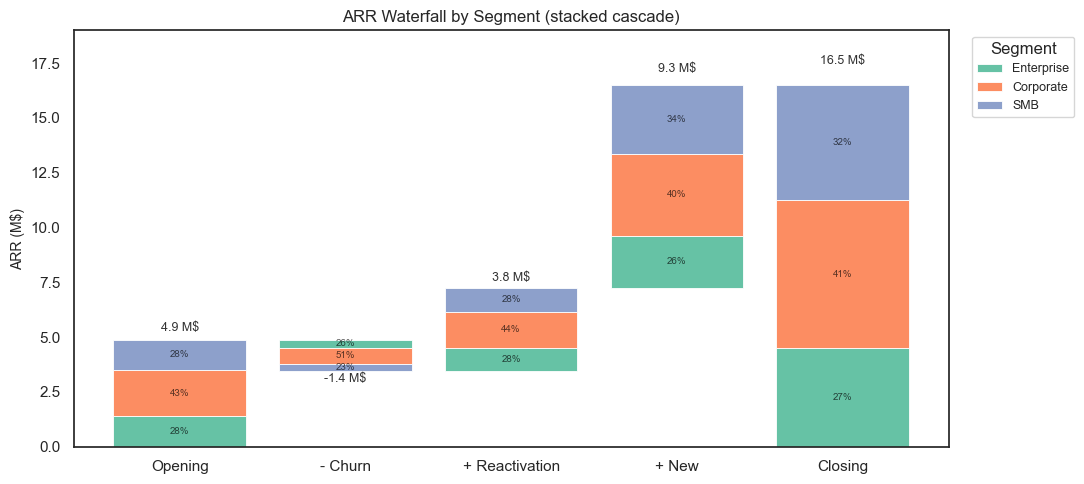

In [108]:

# Stacked waterfall by segment (cascade, M$) with connectors and % overlays
format_pct1 = lambda x: f"{x*100:.0f}%"

seg_water = df.groupby('segment').agg(
    opening_arr=('opening_arr','sum'),
    churned_arr=('churned_arr','sum'),
    reactivated_arr=('reactivated_arr','sum'),
    new_arr=('new_arr','sum')
).reset_index()
seg_water['segment'] = pd.Categorical(seg_water['segment'], categories=segment_order, ordered=True)
seg_water = seg_water.sort_values('segment').reset_index(drop=True)

seg_water['churned_arr'] = -seg_water['churned_arr']  # ensure churn is negative for waterfall
seg_water['closing_arr'] = seg_water['opening_arr'] + seg_water['churned_arr'] + seg_water['reactivated_arr'] + seg_water['new_arr']
steps_order = ['Opening','- Churn','+ Reactivation','+ New','Closing']
value_cols = ['opening_arr','churned_arr','reactivated_arr','new_arr','closing_arr']
step_map = dict(zip(value_cols, steps_order))

long = seg_water.melt(id_vars='segment', value_vars=value_cols, var_name='step_key', value_name='value')
long['Step'] = long['step_key'].map(step_map)
long['value_m'] = long['value'].apply(to_MUSD)
segment_order_present = [s for s in segment_order if s in long['segment'].unique()]
segments = segment_order_present
colors = sns.color_palette('Set2', n_colors=len(segments))
color_map = dict(zip(segments, colors))

# total per step to drive cumulative path
step_totals = long.groupby('Step')['value_m'].sum().reindex(steps_order)
y_start_tot = []
y_end_tot = []
cum = 0
for i, step in enumerate(steps_order):
    if step == 'Opening':
        start = 0; end = step_totals.loc[step]; cum = end
    elif step == 'Closing':
        start = 0; end = step_totals.loc[step]
    else:
        start = cum; end = cum + step_totals.loc[step]; cum = end
    y_start_tot.append(start)
    y_end_tot.append(end)

fig, ax = plt.subplots(figsize=(11,5))
min_y = 0
for x, step in enumerate(steps_order):
    step_df = long[long['Step']==step]
    step_total = step_totals.loc[step]
    base = 0 if step in ['Opening','Closing'] else y_start_tot[x]
    pos_bottom = base
    neg_bottom = base
    for seg_name in segments:
        v_series = step_df.loc[step_df['segment']==seg_name, 'value_m']
        if v_series.empty:
            continue
        v = v_series.iloc[0]
        if v >= 0:
            ax.bar(x, v, bottom=pos_bottom, color=color_map[seg_name], edgecolor='white', linewidth=0.6, label=seg_name if x==0 else "")
            if step not in ['Closing'] and step_total != 0:
                ax.text(x, pos_bottom + v/2, format_pct1(v/step_total), ha='center', va='center', fontsize=7, color='black', alpha=0.65)
            pos_bottom += v
        else:
            ax.bar(x, v, bottom=neg_bottom, color=color_map[seg_name], edgecolor='white', linewidth=0.6, label=seg_name if x==0 else "")
            if step not in ['Closing'] and step_total != 0:
                ax.text(x, neg_bottom + v/2, format_pct1(v/step_total), ha='center', va='center', fontsize=7, color='black', alpha=0.65)
            neg_bottom += v
        min_y = min(min_y, neg_bottom)
  
    # total label with offset to avoid overlapping bars (especially churn)
    label_offset = max(0.05 * abs(step_total), 0.05)
    label_y = (pos_bottom + label_offset) if step_total >= 0 else (neg_bottom - label_offset)
    ax.text(x, label_y, fmt_MUSD(step_total), ha='center', va='bottom' if step_total>=0 else 'top', fontsize=9, color='#333')
  
    # add per-segment labels on closing too
    if step == 'Closing' and step_total != 0:
        step_df = step_df.sort_values('value_m', ascending=False)
        running = 0
        for seg_name in segments:
            v_series = step_df.loc[step_df['segment']==seg_name, 'value_m']
            if v_series.empty:
                continue
            v = v_series.iloc[0]
            center = running + v/2
            ax.text(x, center, format_pct1(v/step_total), ha='center', va='center', fontsize=7, color='black', alpha=0.65)
            running += v

ax.set_xticks(range(len(steps_order)))
ax.set_xticklabels(steps_order)
ax.set_title('ARR Waterfall by Segment (stacked cascade)')
ax.set_ylabel('ARR (M$)')

# Adjust ylim to keep total labels inside frame
y_all = y_end_tot + y_start_tot + [0, min(0, min_y)]
y_max_axis = max(y_all)
y_range = y_max_axis if y_max_axis > 0 else 1
ax.set_ylim(bottom=0, top=y_max_axis + 0.15*y_range)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(False)
plt.tight_layout()
plt.show()



## Benchmarks & definitions 

**Typical ranges (order of magnitude, vary by product & motion):**
- **SMB** gross churn: ~20–35% annual; **Mid‑Market**: ~8–15%; **Enterprise**: ~2–8%
- **Healthy GRR** often **> 90%** (MM/ENT), **NRR** 
  - SMB motion: 100–110% common (if expansion is modest)
  - Enterprise motion: 110–130%+ when expansion is strong

> Notes: This dataset intentionally simulates **acquisition‑led growth** with **fragile retention** and **reactivations**, so absolute levels may be worse than best‑in‑class benchmarks — that is by design.
